# PA-12 — Identification Conducteur / Passager
**Sprint 3 | Équipe P07 | Projet Stellantis**

Deux approches complémentaires :

**Approche A — Enrôlement vocal séquentiel**
L'écran affiche les questions. Le système enregistre chaque réponse séparément → pas besoin de diarisation pour l'enrôlement. Pyannote intervient ensuite pour la conversation.

**Approche B — 2 micros simulés**
Deux enregistrements du même dialogue (micro gauche = conducteur, micro droit = passager). Comparaison RMS pour identifier chaque locuteur.

---

## Scripts d'enregistrement

### Script A — Enrôlement (`enrolement.wav`)
Un seul fichier audio contenant les deux réponses puis la conversation.
Laissez **2 secondes de silence** entre chaque réplique.

```
[silence 2s]
[PERSONNE 1]  "C'est moi, je suis le conducteur."
[silence 2s]
[PERSONNE 2]  "C'est moi, je suis le passager."
[silence 2s]
[PERSONNE 1]  "Bonjour, tu as vu le rapport de ce matin ?"
[PERSONNE 2]  "Oui je l'ai lu, il y a des points intéressants."
[PERSONNE 1]  "On se retrouve à quatorze heures alors ?"
[PERSONNE 2]  "D'accord, à tout à l'heure."
[PERSONNE 1]  "Le client a validé la proposition."
[PERSONNE 2]  "Super, je préviens l'équipe."
```

### Script B — 2 micros (`micro_gauche.wav` + `micro_droite.wav`)
Même dialogue enregistré deux fois, téléphone posé à des positions différentes.
- **micro_gauche.wav** : téléphone à gauche, Personne 1 proche, Personne 2 loin
- **micro_droite.wav** : téléphone à droite, Personne 2 proche, Personne 1 loin

```
[PERSONNE 1]  "Bonjour, tu as vu le rapport de ce matin ?"
[PERSONNE 2]  "Oui je l'ai lu, il y a des points intéressants."
[PERSONNE 1]  "On se retrouve à quatorze heures alors ?"
[PERSONNE 2]  "D'accord, à tout à l'heure."
[PERSONNE 1]  "Le client a validé la proposition."
[PERSONNE 2]  "Super, je préviens l'équipe."
```

**Prérequis :** token HuggingFace configuré dans les secrets Colab (`HF_TOKEN`).

## 1. Installation des dépendances
⚠️ Redémarrer le runtime après cette cellule.

In [ ]:
!pip install -q pyannote.audio silero-vad faster-whisper librosa soundfile pydub
!apt-get install -q ffmpeg
print('✅ Installation OK — redémarre le runtime !')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━

## 2. Chargement des modèles

In [ ]:
import torchaudio, torch, numpy as np, os, json, datetime
import soundfile as sf
import IPython.display as ipd
from pyannote.audio import Pipeline
from pyannote.audio import Model
from pyannote.audio import Inference
from faster_whisper import WhisperModel
from pydub import AudioSegment
from google.colab import userdata, files

# Patch compatibilité torchaudio / pyannote
if not hasattr(torchaudio, 'AudioMetaData'):
    try:
        from torchaudio._backend.utils import AudioMetaData
    except:
        import collections
        AudioMetaData = collections.namedtuple('AudioMetaData',
            ['sample_rate', 'num_frames', 'num_channels', 'bits_per_sample', 'encoding'])
    torchaudio.AudioMetaData = AudioMetaData

# pyannote diarisation
HF_TOKEN = userdata.get('HF_TOKEN')
diarization_pipeline = Pipeline.from_pretrained(
    'pyannote/speaker-diarization-3.1',
    token=HF_TOKEN
)
print('✅ pyannote diarisation chargé')

# pyannote embedding (pour comparer les voix d'enrôlement)
embedding_model = Inference(
    Model.from_pretrained('pyannote/embedding', token=HF_TOKEN),
    window='whole'
)
print('✅ pyannote embedding chargé')

# Silero VAD
vad_model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True
)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils
print('✅ Silero VAD chargé')

# faster-whisper base INT8 — compatible Raspberry Pi
device = 'cuda' if torch.cuda.is_available() else 'cpu'
compute_type = 'float16' if device == 'cuda' else 'int8'
whisper_model = WhisperModel('base', device=device, compute_type=compute_type)
print(f'✅ faster-whisper base chargé ({device}, {compute_type})')

SAMPLE_RATE = 16000
os.makedirs('pa12_audio', exist_ok=True)
print('\n✅ Tous les modèles chargés')

✅ pyannote diarisation chargé


pytorch_model.bin:   0%|          | 0.00/96.4M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/migration/utils.py:197: Redirecting import of pytorch_lightning.callbacks.early_stopping.EarlyStopping to lightning.pytorch.callbacks.early_stopping.EarlyStopping
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/migration/utils.py:197: Redirecting import of pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint to lightning.pytorch.callbacks.model_checkpoint.ModelCheckpoint
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/migration/migration.py:208: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
INFO: Lightning automatically upgraded your loaded checkpoint from v1.2.7 to v2.6.5. To apply the u

✅ pyannote embedding chargé
Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip
✅ Silero VAD chargé
✅ faster-whisper base chargé (cpu, int8)

✅ Tous les modèles chargés


## 3. Fonctions utilitaires

In [ ]:
def convert_audio(filepath, out_name=None):
    audio = AudioSegment.from_file(filepath)
    audio = audio.set_channels(1).set_frame_rate(SAMPLE_RATE)
    name = out_name or os.path.splitext(os.path.basename(filepath))[0]
    out_path = f'pa12_audio/{name}.wav'
    audio.export(out_path, format='wav')
    duration = len(audio) / 1000
    print(f'✅ Converti → {out_path} ({duration:.1f}s)')
    return out_path, duration

def run_vad(audio_1d):
    return get_speech_timestamps(
        audio_1d, vad_model,
        sampling_rate=SAMPLE_RATE,
        threshold=0.4,
        min_speech_duration_ms=200,
        min_silence_duration_ms=100
    )

def transcribe(chunk_path):
    segs, _ = whisper_model.transcribe(chunk_path, language='fr', beam_size=5)
    return ' '.join([s.text for s in segs]).strip().lower()

def get_speaker_at(t, segments, default='UNKNOWN'):
    for seg in segments:
        if seg['start'] <= t <= seg['end']:
            return seg['speaker']
    return default

def compute_rms(audio_array, segments, speaker):
    vals = []
    for seg in segments:
        if seg['speaker'] == speaker:
            chunk = audio_array[int(seg['start']*SAMPLE_RATE):int(seg['end']*SAMPLE_RATE)]
            if len(chunk) > 0:
                vals.append(float(np.sqrt(np.mean(chunk**2))))
    return float(np.mean(vals)) if vals else 0.0

def get_embedding(wav_path):
    return embedding_model({'uri': 'chunk', 'audio': wav_path})

def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

print('✅ Fonctions utilitaires prêtes')

✅ Fonctions utilitaires prêtes


## 4. APPROCHE A — Enrôlement vocal séquentiel

**Logique :**
- Le système affiche la question sur l'écran
- VAD détecte le premier segment de parole → chunk 1 → conducteur
- VAD détecte le second segment de parole → chunk 2 → passager
- Pas de diarisation ici — on sait exactement qui parle grâce à l'ordre des questions
- Ensuite pyannote compare les voix de la conversation aux embeddings d'enrôlement

In [ ]:
print('📂 Upload enrolement.wav...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
AUDIO_ENROL, duration_enrol = convert_audio(filename, 'enrolement')
print('\n🎧 Écoute :')
ipd.display(ipd.Audio(AUDIO_ENROL, rate=SAMPLE_RATE))

📂 Upload enrolement.wav...


Saving Télécom Saint-Étienne 3.m4a to Télécom Saint-Étienne 3.m4a
✅ Converti → pa12_audio/enrolement.wav (25.7s)

🎧 Écoute :


In [ ]:
# Chargement audio
waveform, sr = torchaudio.load(AUDIO_ENROL)
audio_1d     = waveform.squeeze(0)
audio_array  = audio_1d.numpy()

# VAD
speech_timestamps = run_vad(audio_1d)
print(f'🔊 VAD : {len(speech_timestamps)} segment(s) détecté(s)\n')

if len(speech_timestamps) < 2:
    print('⚠️ Moins de 2 segments détectés — vérifiez les silences dans l\'audio')
else:
    # Extraction des 2 premiers chunks = réponses d'enrôlement
    roles = ['conducteur', 'passager']
    questions = ['Qui est le conducteur ?', 'Qui est le passager ?']
    enrollment_chunks = {}   # {role: wav_path}
    enrollment_embeddings = {}  # {role: embedding}

    for idx in range(2):
        ts = speech_timestamps[idx]
        start_s = ts['start'] / SAMPLE_RATE
        end_s   = ts['end']   / SAMPLE_RATE
        chunk   = audio_array[ts['start']:ts['end']]
        chunk_path = f'pa12_audio/enrol_{roles[idx]}.wav'
        sf.write(chunk_path, chunk, SAMPLE_RATE)

        text = transcribe(chunk_path)

        print(f'🖥️  [Écran] {questions[idx]}')
        print(f'  ➜ [{start_s:.2f}s → {end_s:.2f}s] "{text}"')
        ipd.display(ipd.Audio(chunk_path, rate=SAMPLE_RATE))

        enrollment_chunks[roles[idx]] = chunk_path
        enrollment_embeddings[roles[idx]] = get_embedding(chunk_path)
        print(f'  ✅ {roles[idx].upper()} enregistré\n')

    print('=' * 50)
    print('✅ Enrôlement terminé')
    print(f'   Conducteur : {enrollment_chunks["conducteur"]}')
    print(f'   Passager   : {enrollment_chunks["passager"]}')
    print('=' * 50)

🔊 VAD : 10 segment(s) détecté(s)

🖥️  [Écran] Qui est le conducteur ?
  ➜ [3.46s → 5.18s] "et moi, je suis le conducteur."


  ✅ CONDUCTEUR enregistré

🖥️  [Écran] Qui est le passager ?
  ➜ [6.59s → 8.16s] "c'est moi, je suis le passager."


  ✅ PASSAGER enregistré

✅ Enrôlement terminé
   Conducteur : pa12_audio/enrol_conducteur.wav
   Passager   : pa12_audio/enrol_passager.wav


### Suivi post-enrôlement
Pyannote diarise la conversation. Pour chaque locuteur détecté, on compare
son embedding vocal aux embeddings d'enrôlement par similarité cosinus.

In [ ]:
# Diarisation de la conversation complète
diarization = diarization_pipeline(AUDIO_ENROL)
annotation  = diarization.speaker_diarization

diarization_segments = []
for segment, track, speaker in annotation.itertracks(yield_label=True):
    diarization_segments.append({
        'start':   round(segment.start, 3),
        'end':     round(segment.end,   3),
        'speaker': speaker
    })

speakers_found = list(set(s['speaker'] for s in diarization_segments))
print(f'🎙️ Diarisation : {len(speakers_found)} locuteur(s) → {speakers_found}\n')

# Calcul embedding moyen par locuteur pyannote
speaker_embeddings = {}
for spk in speakers_found:
    spk_chunks = []
    for seg in diarization_segments:
        if seg['speaker'] == spk:
            chunk = audio_array[int(seg['start']*SAMPLE_RATE):int(seg['end']*SAMPLE_RATE)]
            if len(chunk) > SAMPLE_RATE * 0.5:  # segments > 0.5s seulement
                chunk_path = f'pa12_audio/spk_{spk}_{len(spk_chunks)}.wav'
                sf.write(chunk_path, chunk, SAMPLE_RATE)
                spk_chunks.append(get_embedding(chunk_path))
    if spk_chunks:
        speaker_embeddings[spk] = np.mean(spk_chunks, axis=0)

# Comparaison avec les embeddings d'enrôlement
role_mapping = {}
print('📊 Similarité cosinus avec les voix d\'enrôlement :\n')
print(f'  {"SPEAKER":<12} {"sim conducteur":>16} {"sim passager":>14} {"→ RÔLE"}')
print('  ' + '-' * 55)

for spk, emb in speaker_embeddings.items():
    sim_cond = cosine_similarity(emb, enrollment_embeddings['conducteur'])
    sim_pass = cosine_similarity(emb, enrollment_embeddings['passager'])
    role = 'conducteur' if sim_cond > sim_pass else 'passager'
    role_mapping[spk] = role
    print(f'  {spk:<12} {sim_cond:>16.4f} {sim_pass:>14.4f}   → {role.upper()}')

print(f'\n✅ Mapping final :')
for spk, role in role_mapping.items():
    print(f'   {spk} → {role.upper()}')

/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


🎙️ Diarisation : 2 locuteur(s) → ['SPEAKER_01', 'SPEAKER_00']

📊 Similarité cosinus avec les voix d'enrôlement :

  SPEAKER        sim conducteur   sim passager → RÔLE
  -------------------------------------------------------
  SPEAKER_01             0.1331         0.7431   → PASSAGER
  SPEAKER_00             0.6144         0.0381   → CONDUCTEUR

✅ Mapping final :
   SPEAKER_01 → PASSAGER
   SPEAKER_00 → CONDUCTEUR


In [ ]:
# Affichage de la conversation avec les rôles
print('\n🎙️ Conversation post-enrôlement avec rôles :\n')
print(f'  {"Seg":<6} {"Locuteur":<12} {"Rôle":<12} {"Transcription"}')
print('  ' + '-' * 75)

# On passe les 2 premiers segments (enrôlement)
for i, ts in enumerate(speech_timestamps[2:], start=2):
    start_s    = ts['start'] / SAMPLE_RATE
    end_s      = ts['end']   / SAMPLE_RATE
    chunk      = audio_array[ts['start']:ts['end']]
    chunk_path = f'pa12_audio/conv_{i:02d}.wav'
    sf.write(chunk_path, chunk, SAMPLE_RATE)

    text    = transcribe(chunk_path)
    speaker = get_speaker_at(start_s + (end_s - start_s) / 2, diarization_segments)
    role    = role_mapping.get(speaker, 'inconnu')

    print(f'  {i+1:02d}     {speaker:<12} {role.upper():<12} "{text[:40]}"')
    ipd.display(ipd.Audio(chunk_path, rate=SAMPLE_RATE))

print('\n✅ Suivi terminé')


🎙️ Conversation post-enrôlement avec rôles :

  Seg    Locuteur     Rôle         Transcription
  ---------------------------------------------------------------------------
  03     SPEAKER_00   CONDUCTEUR   "bonjour, t'as vu le rapport de ce matin "


  04     SPEAKER_01   PASSAGER     "oui, je l'ai lu."


  05     SPEAKER_01   PASSAGER     "il y a des points intéressants."


  06     SPEAKER_00   CONDUCTEUR   "on se retrouve à 14h alors."


  07     SPEAKER_01   PASSAGER     "d'accord, à tout à l'heure."


  08     SPEAKER_00   CONDUCTEUR   "le client va l'idée la proposition."


  09     SPEAKER_01   PASSAGER     "super !"


  10     SPEAKER_01   PASSAGER     "je préviens l'équipe."



✅ Suivi terminé


## 5. APPROCHE B — 2 micros simulés

Upload de deux fichiers audio du même dialogue :
- `micro_gauche.wav` : Personne 1 (conducteur) proche du micro
- `micro_droite.wav` : Personne 2 (passager) proche du micro

Le locuteur dominant (RMS le plus élevé) sur chaque micro est identifié.

In [ ]:
print('📂 Upload micro_gauche.wav...')
up_g = files.upload()
AUDIO_GAUCHE, _ = convert_audio(list(up_g.keys())[0], 'micro_gauche')
print('\n🎧 Micro gauche :')
ipd.display(ipd.Audio(AUDIO_GAUCHE, rate=SAMPLE_RATE))

print('\n📂 Upload micro_droite.wav...')
up_d = files.upload()
AUDIO_DROITE, _ = convert_audio(list(up_d.keys())[0], 'micro_droite')
print('\n🎧 Micro droit :')
ipd.display(ipd.Audio(AUDIO_DROITE, rate=SAMPLE_RATE))

📂 Upload micro_gauche.wav...


Saving Télécom Saint-Étienne 4.m4a to Télécom Saint-Étienne 4.m4a
✅ Converti → pa12_audio/micro_gauche.wav (16.6s)

🎧 Micro gauche :



📂 Upload micro_droite.wav...


Saving Télécom Saint-Étienne 4.m4a to Télécom Saint-Étienne 4 (1).m4a
✅ Converti → pa12_audio/micro_droite.wav (16.6s)

🎧 Micro droit :


In [ ]:
# Diarisation des deux fichiers
print('🎙️ Diarisation micro gauche...')
wf_g, _   = torchaudio.load(AUDIO_GAUCHE)
arr_g     = wf_g.squeeze(0).numpy()
segs_g    = []
diar_g    = diarization_pipeline(AUDIO_GAUCHE)
for seg, _, spk in diar_g.speaker_diarization.itertracks(yield_label=True):
    segs_g.append({'start': round(seg.start,3), 'end': round(seg.end,3), 'speaker': spk})
spks_g = list(set(s['speaker'] for s in segs_g))
print(f'  {len(spks_g)} locuteur(s) : {spks_g}')

print('\n🎙️ Diarisation micro droite...')
wf_d, _   = torchaudio.load(AUDIO_DROITE)
arr_d     = wf_d.squeeze(0).numpy()
segs_d    = []
diar_d    = diarization_pipeline(AUDIO_DROITE)
for seg, _, spk in diar_d.speaker_diarization.itertracks(yield_label=True):
    segs_d.append({'start': round(seg.start,3), 'end': round(seg.end,3), 'speaker': spk})
spks_d = list(set(s['speaker'] for s in segs_d))
print(f'  {len(spks_d)} locuteur(s) : {spks_d}')

🎙️ Diarisation micro gauche...
  1 locuteur(s) : ['SPEAKER_00']

🎙️ Diarisation micro droite...
  1 locuteur(s) : ['SPEAKER_00']


📊 RMS micro gauche :
  SPEAKER_00 : 0.0563  ████████████████████████████

📊 RMS micro droit :
  SPEAKER_00 : 0.0563  ████████████████████████████

  ✅ Conducteur (micro gauche dominant) : SPEAKER_00
  ✅ Passager   (micro droit dominant)   : SPEAKER_00
  Cohérent : ⚠️ non — différence insuffisante


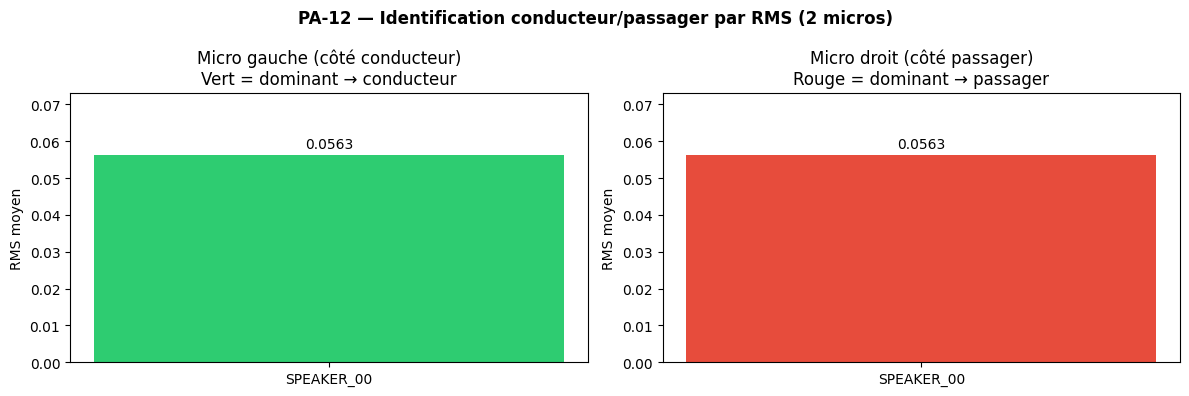

✅ Graphique sauvegardé → pa12_audio/pa12_rms_2micros.png


In [ ]:
import matplotlib.pyplot as plt

# RMS par locuteur sur chaque micro
rms_g = {spk: compute_rms(arr_g, segs_g, spk) for spk in spks_g}
rms_d = {spk: compute_rms(arr_d, segs_d, spk) for spk in spks_d}

print('📊 RMS micro gauche :')
for spk, rms in sorted(rms_g.items(), key=lambda x: x[1], reverse=True):
    print(f'  {spk} : {rms:.4f}  {"█" * int(rms * 500)}')

print('\n📊 RMS micro droit :')
for spk, rms in sorted(rms_d.items(), key=lambda x: x[1], reverse=True):
    print(f'  {spk} : {rms:.4f}  {"█" * int(rms * 500)}')

conducteur_rms = max(rms_g, key=rms_g.get)
passager_rms   = max(rms_d, key=rms_d.get)
coherent       = conducteur_rms != passager_rms

print(f'\n  ✅ Conducteur (micro gauche dominant) : {conducteur_rms}')
print(f'  ✅ Passager   (micro droit dominant)   : {passager_rms}')
print(f'  Cohérent : {"✅ oui" if coherent else "⚠️ non — différence insuffisante"}')

# Graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
cols_g = ['#2ecc71' if s == conducteur_rms else '#95a5a6' for s in spks_g]
cols_d = ['#e74c3c' if s == passager_rms   else '#95a5a6' for s in spks_d]
b1 = ax1.bar(list(rms_g.keys()), list(rms_g.values()), color=cols_g, width=0.4)
ax1.bar_label(b1, fmt='%.4f', padding=3)
ax1.set_title('Micro gauche (côté conducteur)\nVert = dominant → conducteur')
ax1.set_ylabel('RMS moyen')
ax1.set_ylim(0, max(rms_g.values()) * 1.3)
b2 = ax2.bar(list(rms_d.keys()), list(rms_d.values()), color=cols_d, width=0.4)
ax2.bar_label(b2, fmt='%.4f', padding=3)
ax2.set_title('Micro droit (côté passager)\nRouge = dominant → passager')
ax2.set_ylabel('RMS moyen')
ax2.set_ylim(0, max(rms_d.values()) * 1.3)
plt.suptitle('PA-12 — Identification conducteur/passager par RMS (2 micros)', fontweight='bold')
plt.tight_layout()
plt.savefig('pa12_audio/pa12_rms_2micros.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé → pa12_audio/pa12_rms_2micros.png')

## 6. Export JSON — Résultats combinés

In [ ]:
output = {
    'metadata': {
        'story':               'PA-12',
        'processed_at':        datetime.datetime.now().isoformat(),
        'diarization_model':   'pyannote/speaker-diarization-3.1',
        'embedding_model':     'pyannote/embedding',
        'transcription_model': 'faster-whisper-base-int8',
        'contexte_micro':      'plafond centré entre conducteur et passager'
    },
    'approche_A_enrolement': {
        'methode':        'chunks séquentiels + similarité cosinus embeddings',
        'role_mapping':   role_mapping,
        'fiabilite':      'haute — indépendante de la position du micro',
        'recommandation': 'solution principale pour Stellantis'
    },
    'approche_B_2micros': {
        'methode':            'RMS dominant par micro (gauche/droite)',
        'rms_micro_gauche':   rms_g,
        'rms_micro_droite':   rms_d,
        'conducteur_detecte': conducteur_rms,
        'passager_detecte':   passager_rms,
        'coherent':           coherent
    },
    'recommandation_finale': 'Approche A (enrôlement + embeddings) principale — Approche B (2 micros) en complément si hardware disponible'
}

json_path = 'pa12_audio/pa12_output.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('📄 JSON exporté :')
print(json.dumps(output, ensure_ascii=False, indent=2))

## 7. Récapitulatif PA-12

In [ ]:
print('=' * 60)
print('  RÉCAPITULATIF — PA-12 Conducteur / Passager')
print('=' * 60)
print()
print('  APPROCHE A — Enrôlement vocal + embeddings')
for spk, role in role_mapping.items():
    print(f'    {spk} → {role.upper()}')
print()
print('  APPROCHE B — 2 micros simulés')
print(f'    Conducteur (micro gauche) : {conducteur_rms}')
print(f'    Passager   (micro droit)  : {passager_rms}')
print(f'    Cohérent : {"✅ oui" if coherent else "⚠️ non"}')
print()
print('  RECOMMANDATION STELLANTIS')
print('    → Approche A : solution principale (robuste, micro-indépendant)')
print('    → Approche B : complément si 2 micros disponibles dans le véhicule')
print('=' * 60)